In [4]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

### importing toy datasets
sys.path.insert(0,'/hdd/miles/velocity_cfm/dnnlib')
from util import Vanderpol,DoubleCircles,DoubleSDE,Lorenz63,Lorenz96,Rossler,projection,Balls,ToyDsetDynamics


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Generate Data

In [488]:
from sklearn.datasets import make_circles
n_samples = 500
seed = 30
circlesTrain,circlesTest = [make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed
) for _ in range(20)],\
[make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed
) for _ in range(20)]
gen = Lorenz63()#DoubleCircles()
dataTrain = gen.generate(n=20,T=1,dt=0.01,sigma=0.5)
dataTest = gen.generate(n=20,T=1,dt=0.01,sigma=0.5)


In [534]:
def spikify_dataset(train_data,test_data,latent_dim,data_dim,dt):

    mu,sd = np.nanmean(train_data,axis=(0,1),keepdims=True),np.nanstd(train_data,axis=(0,1),keepdims=True)
    w = np.random.randn(latent_dim,data_dim)
    #loading_mat = np.random.uniform(low=0.01,high=0.08,size=(latent_dim,data_dim)) #* np.sign(np.random.randn(latent_dim,data_dim))

    log_rates_train,log_rates_test= (train_data - mu)/sd @ w,(test_data -mu)/sd @ w
    nsteps = train_data.shape[1]
    spikes_train,spikes_test = np.zeros(log_rates_train.shape),np.zeros(log_rates_test.shape)
    for ii in range(nsteps):
        spikes_train[:,ii,:] = np.random.poisson(lam=np.exp(log_rates_train[:,ii,:])*dt) > 0
        spikes_test[:,ii,:] = np.random.poisson(lam=np.exp(log_rates_test[:,ii,:])*dt) > 0

    return spikes_train,spikes_test,np.exp(log_rates_train)*dt,np.exp(log_rates_test)*dt

In [541]:
train_spikes,test_spikes,train_rates,test_rates = spikify_dataset(np.stack(dataTrain,axis=0),np.stack(dataTest,axis=0),latent_dim=3,data_dim=4,dt=0.001)


In [542]:
print(train_spikes.shape)
print(test_spikes.shape)

(20, 100, 4)
(20, 100, 4)


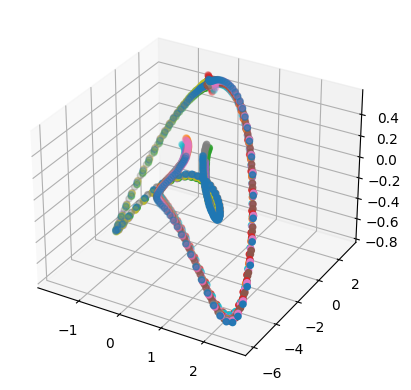

In [543]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
for r in test_rates:
    r /= 0.001
    r = np.log(r)
    ax.scatter(r[:,0],r[:,1],r[:,2])
plt.show()
plt.close()

In [333]:
p = projection(origDim=2,newDim=3,projType='linear',temp=3)

projectedTrain,projectedTest = [p.project(traj) for traj in dataTrain], [p.project(traj) for traj in dataTest]
dsTrain,dsTest = ToyDsetDynamics(projectedTrain,dt=0.001,nForward=0),ToyDsetDynamics(projectedTest,dt=0.001,nForward=0)
dls = {'train':torch.utils.data.DataLoader(dsTrain,batch_size=128,shuffle=True),'val': torch.utils.data.DataLoader(dsTest,batch_size=128,shuffle=False)}

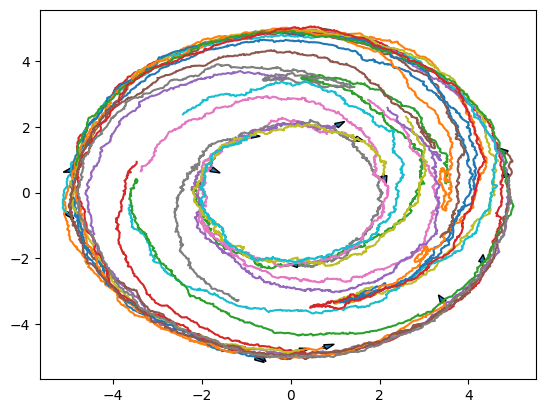

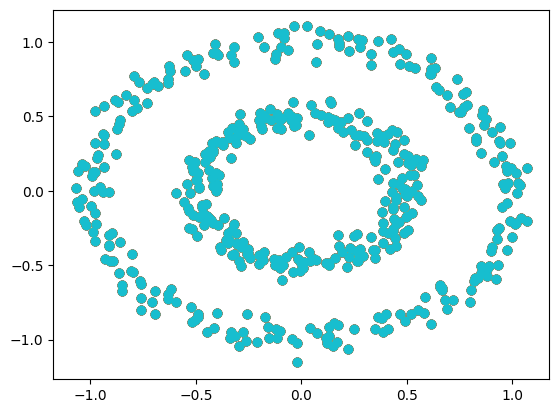

In [334]:
import matplotlib.pyplot as plt
ax = plt.gca()

for swirl in dataTest:
    ax.plot(swirl[:,0],swirl[:,1])
    #ax.scatter(swirl[-1,0],swirl[-1,1])
    #print(swirl.shape)
    dxy = np.diff(swirl,axis=0)
    #print(dxy.shape)
    ax.arrow(swirl[-1,0], swirl[-1,1],dxy[-1,0],dxy[-1,1],width=0.05)
plt.show()
plt.close()

ax = plt.gca()

cs = np.array(['tab:orange','tab:blue'])
for swirl,label in circlesTest:

   
    ax.scatter(swirl[:,0],swirl[:,1])#,c=cs[label])
        
    #ax.scatter(s[0],s[1],color='tab:blue')
    #ax.scatter(swirl[-1,0],swirl[-1,1])
    #print(swirl.shape)
    #dxy = np.diff(swirl,axis=0)
    #print(dxy.shape)
    #ax.arrow(swirl[-1,0], swirl[-1,1],dxy[-1,0],dxy[-1,1],width=0.05)
plt.show()
plt.close()

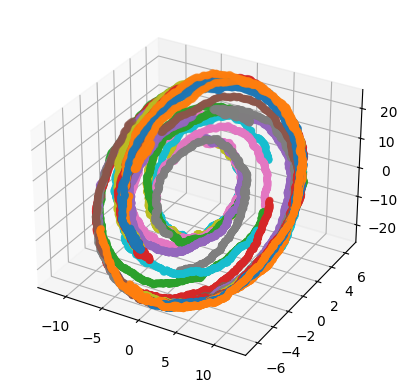

In [335]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

for swirl in projectedTest:
    ax.scatter(swirl[:,0],swirl[:,1],swirl[:,2])
plt.show()
plt.close()

## Create Models

In [297]:
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from torch.distributions import LowRankMultivariateNormal
import os
from abc import ABC,abstractmethod



class AutoEncoder(nn.Module):

    def __init__(self,encoder,decoder,latent_model,save_dir='./autoencoder',loss_fn = nn.MSELoss(reduction='mean'),beta=1):

        super(AutoEncoder,self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.latent_model=latent_model
        self.loss_fn = loss_fn
        self.save_dir=save_dir
        self.epoch=0
        self.beta=beta
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.to(self.device)
        self.writer = SummaryWriter(log_dir=os.path.join(save_dir,'runs'))
        

    def encode(self,x):

        #z = torch.vmap(self.encoder,in_dims=1,out_dims=1)(x)
        #print(x.shape)
        z = self.encoder(x)
        
        z,latent_reg = self.latent_model(z)

        return z,latent_reg

    def decode(self,z):

        return self.decoder(z)

    def forward(self,x):

        #print(x.shape)
        z,latent_reg = self.encode(x)

        xhat = self.decode(z)

        return xhat,latent_reg

    def train_epoch(self,loader,optimizer):

        tl = []
        for ii,batch in enumerate(loader,start=len(loader)*self.epoch):

            optimizer.zero_grad()
            
            data,dt= batch[:-1],batch[-1]
            data = torch.hstack(data).to(self.device)[:,None,:]
            #print(data.shape)
            xhat,latent_reg = self.forward(data)
            #print(xhat.shape)
            #print(data.shape)
            if xhat.shape[1] < data.shape[1]:
                recon_loss = self.loss_fn(xhat,data[:,1:,...])

            else:
                recon_loss = self.loss_fn(xhat,data)
                #print(recon_loss)
        
                
            loss = (self.beta*latent_reg + recon_loss)/len(data)
            #print(loss)
            #assert False
            loss.backward()
            optimizer.step()

            self.writer.add_scalar('Train/recon loss',recon_loss.item(),ii)
            self.writer.add_scalar('Train/latent regularization',latent_reg.item(),ii)
            tl.append(loss.item())
        self.epoch += 1

        return tl,optimizer

    def val_epoch(self,loader):

        vl = []
        reg = []
        recon = []
        with torch.no_grad():

            for batch in loader:
                data,dt= batch[:-1],batch[-1]
                
                #data = torch.stack(data,axis=1).to(self.device)
                data = torch.hstack(data).to(self.device)[:,None,:]

                xhat,latent_reg = self.forward(data)
                if xhat.shape[1] < data.shape[1]:
                    recon_loss = self.loss_fn(xhat,data[:,1:,...])
    
                else:
                    #print("lossin' it up")
                    recon_loss = self.loss_fn(xhat,data)
                loss = (self.beta*latent_reg + recon_loss)/len(data)
                vl.append(loss.item())
                reg.append(latent_reg.item())
                recon.append(recon_loss.item())
            self.writer.add_scalar('Val/recon loss',np.nanmean(recon),self.epoch)
            self.writer.add_scalar('Val/latent regularization',np.nanmean(reg),self.epoch)

        return vl

    def save(self,optimizer):

        state_dict_full = {'model_dict':self.state_dict(),'opt_dict':optimizer.state_dict(),'epoch':self.epoch}
        torch.save(state_dict_full,os.path.join(self.save_dir,f'checkpoint_{self.epoch}.tar'))

    def load(self,path,optimizer):

        state_dict = torch.load(path)
        optimizer.load_state_dict(state_dict['opt_dict'])
        self.load_state_dict(state_dict['model_dict'])
        self.epoch = state_dict['epoch']
        return optimizer
            
class LatentLSTM(nn.Module):
    
    def __init__(self,input_size,hidden_size,num_layers,loss_fn=nn.MSELoss(reduction='mean')):

        super().__init__()

        self.net = nn.LSTM(input_size=input_size,hidden_size=hidden_size,num_layers=num_layers,batch_first=True)
        self.output = nn.Linear(hidden_size,input_size)
        self.loss_fn = loss_fn

    def forward(self,x):

        x,y = x[:,:-1,...],x[:,1:,...]
        out,_ = self.net(x)
        yhat = self.output(out)
        return yhat,self.loss_fn(yhat,y)

class LatentVAE(nn.Module):
    
    def __init__(self,input_size,output_size,num_hidden,hidden_size=10):

        super().__init__()

        mu = [nn.Linear(input_size,hidden_size,bias=True), nn.ReLU()]
        u = [nn.Linear(input_size,hidden_size,bias=True),nn.ReLU()]
        d = [nn.Linear(input_size,hidden_size,bias=True),nn.ReLU()]
        for _ in range(num_hidden):
            mu.append(nn.Linear(hidden_size,hidden_size))
            mu.append(nn.ReLU())
            u.append(nn.Linear(hidden_size,hidden_size))
            u.append(nn.ReLU())
            d.append(nn.Linear(hidden_size,hidden_size))
            d.append(nn.ReLU())
        mu.append(nn.Linear(hidden_size,output_size))
        u.append(nn.Linear(hidden_size,output_size))
        d.append(nn.Linear(hidden_size,output_size))

        self.mu = nn.Sequential(*mu)
        self.u = nn.Sequential(*u)
        self.d = nn.Sequential(*d)

    def forward(self,x):

        mu,u,d = self.mu(x),self.u(x),self.d(x)
        u = u.unsqueeze(-1)
        d = torch.exp(d)
        
        latent_dist = LowRankMultivariateNormal(mu, u, d)
        z = latent_dist.rsample()
        #print(z.shape)
        #print(latent_dist.entropy().shape)
        
        kl_term = -0.5 * (torch.sum(torch.pow(z,2),axis=-1) + z.shape[-1] * np.log(2*np.pi))
        #assert False
        kl_term = kl_term.sum() + torch.sum(latent_dist.entropy())
        
        
        return z,-kl_term

class LatentAC(nn.Module):

        def __init__(self):
            super().__init__()

        def forward(self,x):
            return x,torch.tensor([0]).type(torch.FloatTensor).to(x.device)


class Encoder(nn.Module):
    
    def __init__(self):

        super().__init__()

        
    @abstractmethod
    def forward(self,x):
        raise NotImplementedError


class Decoder(nn.Module):

    def __init__(self):

        super().__init__()

    @abstractmethod
    def forward(self,x):
        raise NotImplementedError

class Linear(Encoder,Decoder):

    def __init__(self,in_dim,out_dim,has_bias=True):

        super(LinearDecoder,self).__init__()

        self.net = nn.Linear(in_dim,out_dim,bias=has_bias)

    def forward(self,x):
        return self.net(x)

    

class CirclePredictor(nn.Module):

    def __init__(self,input_size,hidden_size,num_layers,save_dir='./circle_model',loss_fn = nn.MSELoss(reduction='mean')):

        super().__init__()

        self.lstm = nn.LSTM(input_size=input_size,hidden_size=hidden_size,num_layers=num_layers)
        self.output = nn.Linear(hidden_size,input_size)

        self.save_dir=save_dir
        if not os.path.isdir(save_dir):
            os.mkdir(save_dir)
        self.loss_fn = loss_fn

        self.epoch = 0
        if torch.cuda.is_available(): 
            self.device='cuda' 
            self.to(torch.device('cuda'))
        else:
            self.device='cpu'
        self.writer = SummaryWriter(log_dir=os.path.join(save_dir,'runs'))
        
    def forward(self,x):

        output,(h_n,c_n) = self.lstm(x)

        output = self.output(output)

        return output,(h_n,c_n)

    def train_epoch(self, loader, optimizer):

        optimizer.zero_grad()
        tl = []
        for ii,batch in enumerate(loader,start=self.epoch*len(loader)):

            data,dt= batch[:-1],batch[-1]
            #print(batch)
            x,y = torch.stack(data[:-1],axis=1).to(self.device),torch.stack(data[1:],axis=1).to(self.device)
            out,(h_n,c_n) = self.forward(x)

            train_loss = self.loss_fn(out,y)
            train_loss.backward()
            optimizer.step()
            self.writer.add_scalar('Train/loss',train_loss.item(),ii)
            tl.append(train_loss.item())

        self.epoch += 1

        return tl,optimizer

    def val_epoch(self,loader):

        vl = []
        with torch.no_grad():

            for batch in loader:
                data,dt= batch[:-1],batch[-1]
                
                x,y = torch.stack(data[:-1],axis=1).to(self.device),torch.stack(data[1:],axis=1).to(self.device)
                out,(h_n,c_n) = self.forward(x)
    
                val_loss = self.loss_fn(out,y)
                vl.append(val_loss.item())
            self.writer.add_scalar('Val/loss',np.nanmean(vl),self.epoch)

        return vl

    def save(self,optimizer):

        state_dict_full = {'model_dict':self.state_dict(),'opt_dict':optimizer.state_dict(),'epoch':self.epoch}
        torch.save(state_dict_full,os.path.join(self.save_dir,f'checkpoint_{self.epoch}.tar'))

    def load(self,path,optimizer):

        state_dict = torch.load(path)
        optimizer.load_state_dict(state_dict['opt_dict'])
        self.load_state_dict(state_dict['model_dict'])
        self.epoch = state_dict['epoch']
        return optimizer

            
            
        

In [320]:
from torch.optim import Adam
enc = nn.Sequential(*[nn.Linear(3,6,bias=True),
                     nn.ReLU(),
                     nn.Linear(6,3,bias=True),
                     nn.ReLU(),
                     nn.Linear(3,2,bias=True)])
dec = nn.Sequential(*[nn.Linear(2,3,bias=True),
                     nn.ReLU(),
                     nn.Linear(3,6,bias=True),
                     nn.ReLU(),
                     nn.Linear(6,3,bias=True)])
#latent_model = LatentVAE(input_size=2,output_size=2,num_hidden=1,hidden_size=5)
latent_model = LatentAC()
#latent_model = LatentLSTM(input_size=2,hidden_size=2,num_layers=2,loss_fn = lambda x,y: 0.1 * nn.MSELoss(reduction='mean')(x,y))

ac = AutoEncoder(enc,dec,latent_model=latent_model,save_dir='/home/miles/isilon/All_Staff/miles/models/circle_lstm_ac_nonlinear_weightedloss',loss_fn = lambda x,y: (1e-3*(x-y)**2 ).sum(),beta=1.)

opt = Adam(ac.parameters(),lr=1e-2)

In [321]:
batch = next(iter(dls['train']))

b = torch.hstack(batch[:-1]).to(ac.device)
print(b.shape)
c = ac(b)

torch.Size([128, 3])


In [322]:
print(b.shape,c[0].shape)

torch.Size([128, 3]) torch.Size([128, 3])


## Train

In [323]:
from tqdm import tqdm
def train(model,optimizer,loaders,nEpochs=100,save_freq=25):

    train_losses,test_losses,val_losses = [],[],[]
    for epoch in tqdm(range(nEpochs),desc='training model'):

        model.train()

        train_loss,optimizer = model.train_epoch(loaders['train'],optimizer)

        model.eval()
        val_loss = model.val_epoch(loaders['val'])

        if epoch % save_freq == 0:
            model.save(optimizer)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return train_losses,val_losses,model,optimizer


def predict(model,trajectory):

    model.eval()
    trajectory = torch.from_numpy(trajectory).type(torch.FloatTensor).to(model.device)[None,...]
    #print(trajectory.shape)
    x = trajectory[:,:-1,...]
    y = trajectory[:,1:,...]

    
    yhat,_ = model(x)

    return yhat.detach().cpu().numpy().squeeze()


def embed(model,trajectory):

    model.eval()
    trajectory = torch.from_numpy(trajectory).type(torch.FloatTensor).to(model.device)[None,...]
    #print(trajectory.shape)
    #z = torch.vmap(model.encoder,in_dims=1,out_dims=1)(trajectory)
    #print(z.shape)
    x = trajectory[:,:-1,...]
    y = trajectory[:,1:,...]

    yhat,_ = model.encode(x)
    return yhat.detach().cpu().numpy().squeeze()

In [336]:
train_loss,test_loss,model,opt = train(ac,opt,dls,nEpochs=100)

training model: 100%|█| 100/100 [01:19<00:


## Evaluate

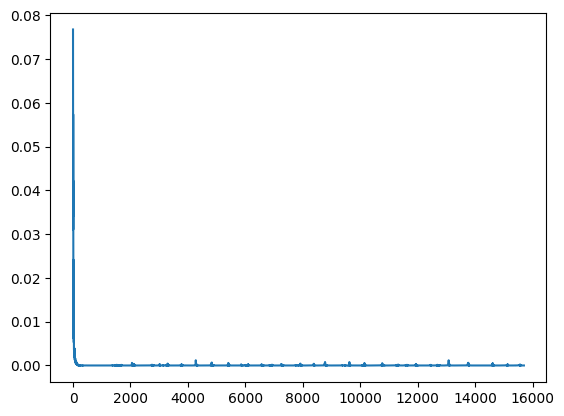

In [337]:
ax = plt.gca()
ax.plot(np.hstack(train_loss))
plt.show()
plt.close()

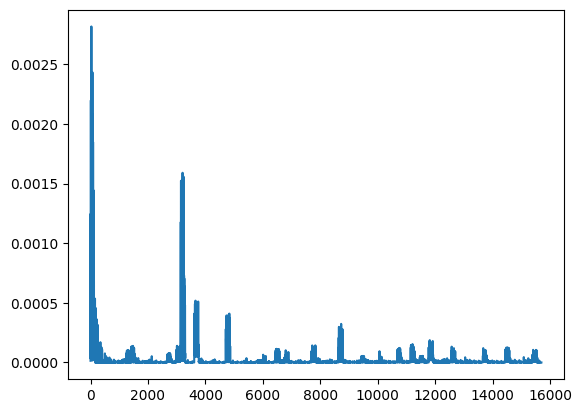

In [338]:
ax = plt.gca()
ax.plot(np.hstack(test_loss))
plt.show()
plt.close()

In [339]:
def format_input(traj,nforward):

    samples = []
    for ii in range(len(traj)-nforward):
        samples.append(traj[ii:ii+nforward+1].reshape(1,-1))

    #print(samples[-1].shape)
    return np.vstack(samples)

    

In [340]:
pred_test = [predict(model,traj) for traj in projectedTest]
latents_test = [embed(model,traj) for traj in projectedTest]

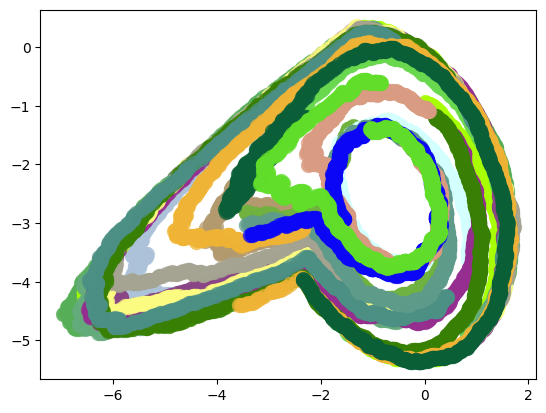

In [341]:
import matplotlib.colors as mcolors
colornames = list(mcolors.XKCD_COLORS.keys())
ax = plt.gca()
for true,pred,color in zip(dataTest,latents_test,colornames):
    #print(pred.shape)
    true = true[1:]
    #ax.plot(true[:,0],true[:,1],color=color,linestyle='solid',linewidth=1.5,alpha=1)
    ax.scatter(pred[:,0],pred[:,1],color=color,linestyle='solid',linewidth=5,alpha=0.75)

plt.show()
plt.close()



In [342]:
print(pred_test[0].shape)

(999, 3)


[0.36298254 0.14445507 0.37756796]
[-5.6873493 -3.4394507 -9.954528 ]
[0.5103255  0.36311683 1.07972124]
[ -5.0194693  -3.74727   -11.227312 ]
[-2.47099829  0.74994828  3.37508914]
[-8.352251    0.71910286  5.175791  ]
[-0.12232902  0.12068023  0.45367855]
[8.548452   0.876192   0.22647786]
[-0.34426036 -0.42053666 -1.33062205]
[ 2.0398858  4.4822197 14.709482 ]
[ 0.246566   -0.11706505 -0.48163819]
[-8.423485  -1.4205947 -2.1408095]
[-1.06567558 -0.08580863  0.05187025]
[-3.5505457  3.8306165 14.289579 ]
[ 0.42717923  0.03225163 -0.02814982]
[  2.180655   -4.3864636 -15.758013 ]
[-0.05972289  0.35394924  1.23346311]
[ -5.087135   -3.5366569 -10.482879 ]
[-0.232513    0.51584703  1.84491258]
[ 8.636744   -0.83787096 -5.681883  ]
[0.81554296 0.37897857 1.03497412]
[ -3.7286963  -4.099589  -12.855011 ]
[0.51860521 0.144898   0.32853133]
[-8.338313   0.7733436  5.357325 ]
[-0.50118649  0.31551854  1.2450589 ]
[ 8.463364    0.09795952 -2.4154344 ]
[0.33909166 0.08484364 0.18085939]
[ -4.31

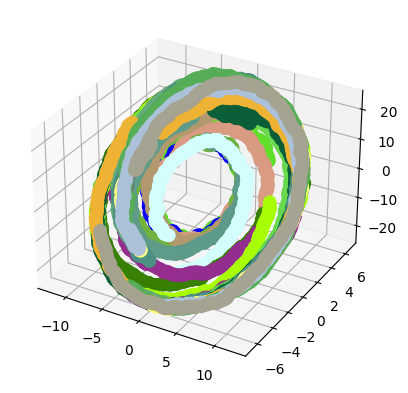

In [343]:
colornames = list(mcolors.XKCD_COLORS.keys())
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
for true,pred,color in zip(projectedTest,pred_test,colornames):
    #print(pred.shape)
    true = true[1:]
    print(np.nanmean(true,axis=0))
    print(pred[0])
    #ax.plot(true[:,0],true[:,1],color=color,linestyle='solid',linewidth=1.5,alpha=1)
    ax.scatter(pred[:,0],pred[:,1],pred[:,2],color=color,linestyle='solid',linewidth=5,alpha=0.75)

plt.show()
plt.close()